In [1]:
# ============================================
# Customer Churn Prediction - Olist Dataset
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve)
import warnings
warnings.filterwarnings('ignore')
print("All libraries uploaded successfully!")

All libraries uploaded successfully!


In [2]:
# Step 2 - Load Data
customers = pd.read_csv(r"C:\Users\venka\OneDrive\Desktop\Customer-Churn-Prediction\Data\olist_customers_dataset.csv")
orders = pd.read_csv(r"C:\Users\venka\OneDrive\Desktop\Customer-Churn-Prediction\Data\olist_orders_dataset.csv")
order_items = pd.read_csv(r"C:\Users\venka\OneDrive\Desktop\Customer-Churn-Prediction\Data\olist_order_items_dataset.csv")
order_payments = pd.read_csv(r"C:\Users\venka\OneDrive\Desktop\Customer-Churn-Prediction\Data\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(r"C:\Users\venka\OneDrive\Desktop\Customer-Churn-Prediction\Data\olist_order_reviews_dataset.csv")

print("All datasets loaded successfully! ✅")
print(f"Customers: {customers.shape}")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")

All datasets loaded successfully! ✅
Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)


In [3]:
# Step 3 - Merge Datasets
df=orders.merge(customers, on='customer_id',how='left')
df=df.merge(order_items, on='order_id', how='left')
df=df.merge(order_payments, on='order_id',how='left')
df=df.merge(order_reviews, on='order_id',how='left')

print ("All datas loaded successfully!")
print(f"Final dataframe shape : {df.shape}")
print(f"Columns:{df.columns.tolist()}")

All datas loaded successfully!
Final dataframe shape : (119143, 28)
Columns:['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [4]:

# Step 4 - Define Churn 


orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Merge orders with customers to get customer_unique_id
orders_customers = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

customer_orders = orders_customers.groupby('customer_unique_id').agg(
    total_orders = ('order_id', 'count'),
    last_purchase = ('order_purchase_timestamp', 'max')
).reset_index()

reference_date = orders['order_purchase_timestamp'].max()

customer_orders['days_since_last_purchase'] = (reference_date - customer_orders['last_purchase']).dt.days

customer_orders['churn'] = (customer_orders['days_since_last_purchase'] > 180).astype(int)

print("Churn defined successfully! ✅")
print(f"Total Customers: {customer_orders.shape[0]}")
print(f"Churned Customers: {customer_orders['churn'].sum()}")
print(f"Active Customers: {(customer_orders['churn'] == 0).sum()}")
print(f"Churn Rate: {round(customer_orders['churn'].mean() * 100, 2)}%")

Churn defined successfully! ✅
Total Customers: 96096
Churned Customers: 68115
Active Customers: 27981
Churn Rate: 70.88%


In [5]:
print(orders_customers.shape)
print(orders_customers.columns.tolist())
print(orders_customers.head())

(99441, 9)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered   

In [6]:
# Step 5 - Feature Engineering
payment_features = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'mean'),
    payment_type=('payment_type', 'first')
).reset_index()

review_features = order_reviews.groupby('order_id').agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

final_df = orders_customers.merge(payment_features, on='order_id', how='left')
final_df = final_df.merge(review_features, on='order_id', how='left')

customer_features = final_df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'count'),
    total_spend=('total_payment', 'sum'),
    avg_spend=('total_payment', 'mean'),
    avg_review_score=('avg_review_score', 'mean'),
    avg_installments=('payment_installments', 'mean')
).reset_index()

customer_features = customer_features.merge(
    customer_orders[['customer_unique_id', 'days_since_last_purchase', 'churn']],
    on='customer_unique_id', how='left'
)

print("Feature Engineering done!")
print(f"Shape: {customer_features.shape}")
print(customer_features.head())

Feature Engineering done!
Shape: (96096, 8)
                 customer_unique_id  total_orders  total_spend  avg_spend  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1       141.90     141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1        27.19      27.19   
2  0000f46a3911fa3c0805444483337064             1        86.22      86.22   
3  0000f6ccb0745a6a4b88665a16c9f078             1        43.62      43.62   
4  0004aac84e0df4da2b147fca70cf8255             1       196.89     196.89   

   avg_review_score  avg_installments  days_since_last_purchase  churn  
0               5.0               8.0                       160      0  
1               4.0               1.0                       163      0  
2               3.0               8.0                       585      1  
3               4.0               4.0                       369      1  
4               5.0               6.0                       336      1  


In [7]:
# Step 6 - Data Cleaning
print("Missing Values before Cleaning:")
print(customer_features.isnull().sum())


customer_features['avg_review_score'] = customer_features['avg_review_score'].fillna(customer_features['avg_review_score'].median())
customer_features['avg_installments'].fillna(1,inplace=True)
customer_features['total_spend'].fillna(0,inplace=True)
customer_features['avg_spend'].fillna(0,inplace=True)


print("\n Missing values after cleaning:")
print(customer_features.isnull().sum())

print("\n Data cleaning done!")
print(f"Final Shape:{customer_features.shape}")



Missing Values before Cleaning:
customer_unique_id            0
total_orders                  0
total_spend                   0
avg_spend                     1
avg_review_score            716
avg_installments              1
days_since_last_purchase      0
churn                         0
dtype: int64

 Missing values after cleaning:
customer_unique_id          0
total_orders                0
total_spend                 0
avg_spend                   0
avg_review_score            0
avg_installments            0
days_since_last_purchase    0
churn                       0
dtype: int64

 Data cleaning done!
Final Shape:(96096, 8)


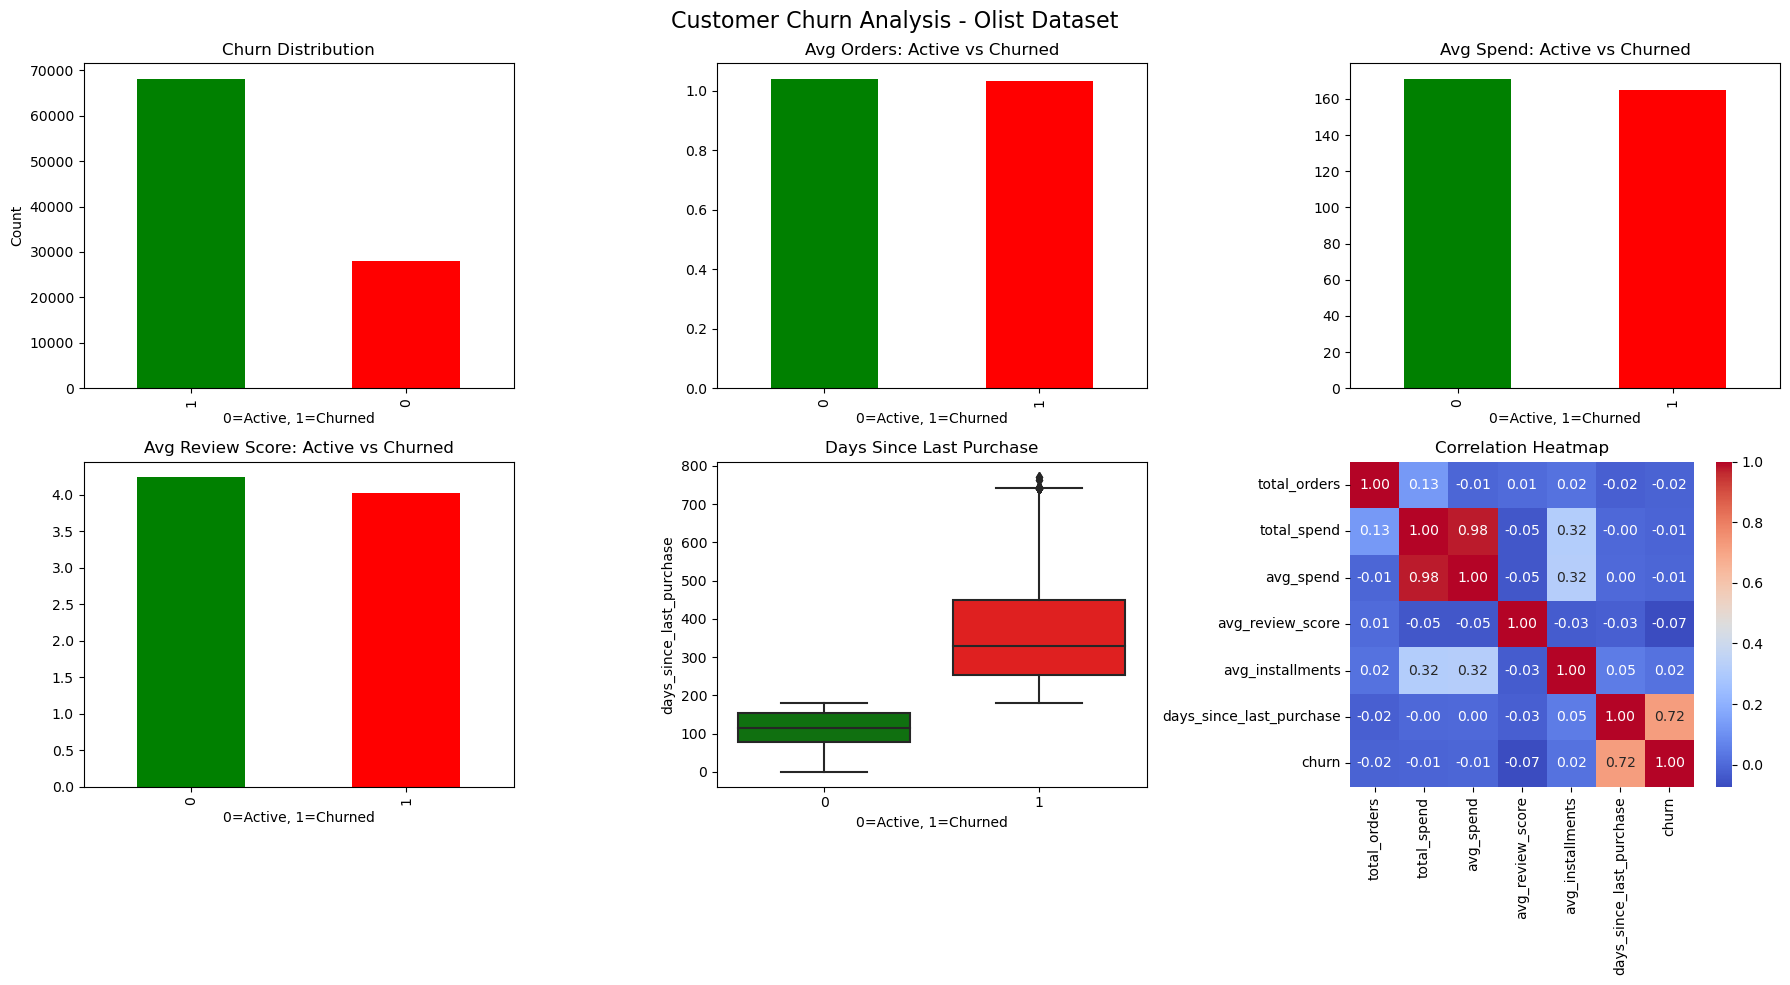

EDA Done! ✅


In [8]:
# Step 7 - EDA 

import os
os.makedirs('../images', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn Analysis - Olist Dataset', fontsize=16)

# 1. Churn Distribution
customer_features['churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('0=Active, 1=Churned')
axes[0,0].set_ylabel('Count')

# 2. Total Orders vs Churn
customer_features.groupby('churn')['total_orders'].mean().plot(kind='bar', ax=axes[0,1], color=['green','red'])
axes[0,1].set_title('Avg Orders: Active vs Churned')
axes[0,1].set_xlabel('0=Active, 1=Churned')

# 3. Total Spend vs Churn
customer_features.groupby('churn')['total_spend'].mean().plot(kind='bar', ax=axes[0,2], color=['green','red'])
axes[0,2].set_title('Avg Spend: Active vs Churned')
axes[0,2].set_xlabel('0=Active, 1=Churned')

# 4. Review Score vs Churn
customer_features.groupby('churn')['avg_review_score'].mean().plot(kind='bar', ax=axes[1,0], color=['green','red'])
axes[1,0].set_title('Avg Review Score: Active vs Churned')
axes[1,0].set_xlabel('0=Active, 1=Churned')

# 5. Days since last purchase
sns.boxplot(x='churn', y='days_since_last_purchase', data=customer_features, ax=axes[1,1], palette=['green','red'])
axes[1,1].set_title('Days Since Last Purchase')
axes[1,1].set_xlabel('0=Active, 1=Churned')

# 6. Correlation Heatmap
numeric_cols = customer_features.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../images/eda_charts.png')
plt.show()
print("EDA Done! ✅")






In [9]:

# Step 8 Model building

from sklearn.utils import resample

# Separate majority and minority classes
churned = customer_features[customer_features['churn'] == 1]
active = customer_features[customer_features['churn'] == 0]

# Undersample majority class
churned_downsampled = resample(churned, 
                               replace=False,
                               n_samples=len(active),
                               random_state=42)

# Combine balanced dataset
balanced_df = pd.concat([churned_downsampled, active])

# Remove days_since_last_purchase (data leakage!)
X = balanced_df[['total_orders', 'total_spend', 'avg_spend',
                 'avg_review_score', 'avg_installments']]
y = balanced_df['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 - Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Model 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print(f"\nLogistic Regression Accuracy: {round(lr_model.score(X_test_scaled, y_test)*100, 2)}%")
print(f"Random Forest Accuracy: {round(rf_model.score(X_test_scaled, y_test)*100, 2)}%")

print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))


Logistic Regression Accuracy: 54.14%
Random Forest Accuracy: 60.1%

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.54      0.68      0.60      5643
           1       0.55      0.40      0.46      5550

    accuracy                           0.54     11193
   macro avg       0.54      0.54      0.53     11193
weighted avg       0.54      0.54      0.53     11193


Random Forest Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60      5643
           1       0.60      0.60      0.60      5550

    accuracy                           0.60     11193
   macro avg       0.60      0.60      0.60     11193
weighted avg       0.60      0.60      0.60     11193



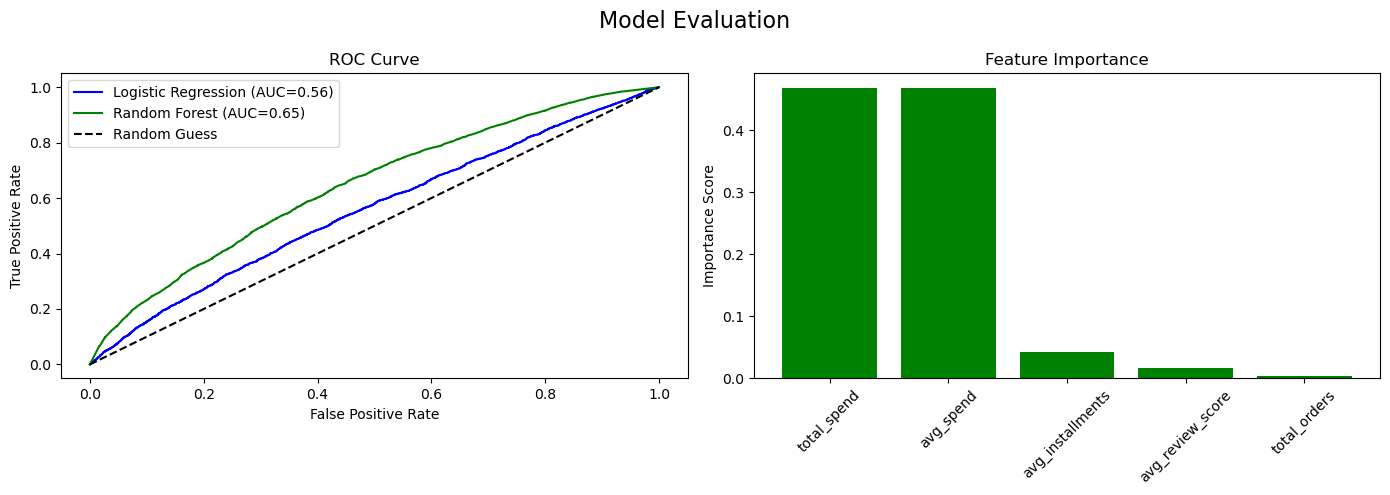


Logistic Regression AUC: 0.56
Random Forest AUC: 0.65

Project Complete! 


In [10]:

# Step 9 - ROC Curve & Feature Importance 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=16)

# ROC Curve
lr_proba = lr_model.predict_proba(X_test_scaled)[:,1]
rf_proba = rf_model.predict_proba(X_test_scaled)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

axes[0].plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_auc:.2f})', color='blue')
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_auc:.2f})', color='green')
axes[0].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Feature Importance
feature_names = ['total_orders', 'total_spend', 'avg_spend',
                 'avg_review_score', 'avg_installments']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

axes[1].bar(range(len(feature_names)), importances[indices], color='green')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels([feature_names[i] for i in indices], rotation=45)
axes[1].set_title('Feature Importance')
axes[1].set_ylabel('Importance Score')

plt.tight_layout()
plt.savefig('../images/model_evaluation.png')
plt.show()

print(f"\nLogistic Regression AUC: {lr_auc:.2f}")
print(f"Random Forest AUC: {rf_auc:.2f}")
print("\nProject Complete! ")